# Item Classifier (Phase 2)

Goal: train a small item classifier that predicts the item label from captured RGB images.

This notebook keeps model training separate from the pipeline code.

Expected data layout:
- data/raw/realsense/labelled/<item_label>/*.png

Optional: build the labeled image set from the IKEA cleaned reference table at:
- data/interim/ikea_reference_cleaned.csv (uses the `url` column)

In [1]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_root = project_root / 'data' / 'raw' / 'realsense' / 'labelled'
data_root

WindowsPath('d:/Green Waste/V1_GreenWaste/data/raw/realsense/labelled')

## 1) Download IKEA images (optional)

This uses the `url` column from `data/interim/ikea_reference_cleaned.csv` and saves images into label folders.

## 2) Verify labeled data

In [2]:
import time
from pathlib import Path
from urllib.parse import urlparse
from urllib.request import urlretrieve

import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
label_root = project_root / 'data' / 'raw' / 'realsense' / 'labelled'
source_csv = project_root / 'data' / 'interim' / 'ikea_reference_cleaned.csv'

max_per_label = 500
max_total = 20000
sleep_seconds = 0.2

if not source_csv.exists():
    raise FileNotFoundError(f"Missing source CSV: {source_csv}")

df = pd.read_csv(source_csv)
df = df.dropna(subset=['url', 'item_label'])
df['url'] = df['url'].astype(str)
df['item_label'] = df['item_label'].astype(str)

counts = {}
total = 0
failures = 0

for _, row in df.iterrows():
    label = row['item_label'].strip()
    url = row['url'].strip()
    if not label or not url:
        continue
    counts.setdefault(label, 0)
    if counts[label] >= max_per_label or total >= max_total:
        continue

    label_dir = label_root / label
    label_dir.mkdir(parents=True, exist_ok=True)

    filename = Path(urlparse(url).path).name or f"img_{counts[label]:04d}.jpg"
    target_path = label_dir / filename
    if target_path.exists():
        counts[label] += 1
        total += 1
        continue

    try:
        urlretrieve(url, target_path)
        counts[label] += 1
        total += 1
        time.sleep(sleep_seconds)
    except Exception:
        failures += 1
        continue

total, failures, len(counts)

(2145, 0, 189)

In [3]:
image_extensions = ('.png', '.jpg', '.jpeg', '.webp')

def image_files(folder):
    return sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in image_extensions)

labels = sorted([p.name for p in label_root.iterdir() if p.is_dir()]) if label_root.exists() else []
label_counts = {label: len(image_files(label_root / label)) for label in labels}
labels, label_counts

(['baby_kids_baby_baby_proofing_child_safety',
  'baby_kids_baby_baby_textiles_baby_blankets_quilts',
  'baby_kids_baby_baby_textiles_crib_bedding_fitted_sheets',
  'baby_kids_baby_changing_bathing_potty_changing_accessories',
  'baby_kids_baby_cribs_crib_mattresses_cribs',
  'baby_kids_baby_kids_night_lights_lamps',
  'baby_kids_baby_kids_storage_organization_sm_stad_system_frames_for_sm_stad',
  'baby_kids_baby_kids_storage_organization_sm_stad_system_sm_stad_combinations',
  'baby_kids_baby_nursery_furniture_changing_tables',
  'baby_kids_kids_kids_study_furniture_accessories_kids_decoration_accessories',
  'baby_kids_kids_kids_study_furniture_accessories_kids_desks',
  'baby_kids_kids_textiles_for_kids_kids_bed_tents_canopies',
  'bathroom_furniture_supplies_more_bathroom_carts',
  'bathroom_furniture_supplies_more_bathroom_stools_benches',
  'beds_mattresses_beds_daybeds',
  'beds_mattresses_beds_kids_beds_junior_extendable_beds',
  'beds_mattresses_beds_kids_beds_kids_single_beds

In [4]:
import hashlib
from collections import Counter

def broad_item_label(raw_label):
    label = raw_label.lower()

    accessory_terms = (
        'accessories', 'parts', 'cover', 'covers', 'cushion', 'pad',
        'blanket', 'sheet', 'textile', 'curtain', 'canopy', 'topper',
    )
    if any(term in label for term in accessory_terms):
        return None

    if any(term in label for term in ('sofa', 'loveseat', 'sectional', 'futon')):
        return 'sofa'
    if any(term in label for term in ('bed', 'crib', 'mattress')):
        return 'beds_mattresses'
    if any(term in label for term in (
        'storage', 'cabinet', 'wardrobe', 'dresser', 'drawer', 'shelf',
        'shelves', 'bookcase', 'bookshelf', 'cart', 'basket', 'organizer',
        'sideboard', 'tv_stands',
    )):
        return 'storage'
    if any(term in label for term in (
        'computer_desks', 'office_desks', 'gaming_desks', 'kids_desks',
        'children_s_desk', 'desks_for_home', 'desks_for_office', 'laptop_tables',
        'conference_meeting_tables', 'conference_tables', 'meeting_tables',
        'dining_tables', 'coffee_tables', 'side_tables', 'end_tables',
        'nesting_tables', 'bar_tables', 'round_tables', 'extendable_tables',
        'multifunctional_tables', 'dining_sets', 'bistro_sets',
        'outdoor_dining_sets', 'table_tops', 'nightstands', 'changing_tables',
        'vanities',
    )):
        return 'tables_desks'
    if any(term in label for term in (
        'dining_chairs', 'upholstered_chairs', 'outdoor_dining_chairs',
        'outdoor_patio_lounge_chairs', 'gaming_chairs', 'conference_chairs',
        'desk_chairs', 'armchairs', 'stools', 'benches', 'bar_stools',
        'high_chairs', 'kids_chairs', 'lounge_chairs', 'reclining_chairs',
        'chaise',
    )):
        return 'chair_seating'

    return None

# Collect all image paths and broad labels from labeled folders
image_paths = []
image_labels = []
raw_to_broad_label = {}
for label in labels:
    broad_label = broad_item_label(label)
    raw_to_broad_label[label] = broad_label
    if broad_label is None:
        continue
    for img_path in image_files(data_root / label):
        image_paths.append(img_path)
        image_labels.append(broad_label)

# Deduplicate by file hash
seen_hashes = set()
deduped_paths = []
deduped_labels = []

for path, label in zip(image_paths, image_labels):
    file_hash = hashlib.md5(path.read_bytes()).hexdigest()
    if file_hash not in seen_hashes:
        seen_hashes.add(file_hash)
        deduped_paths.append(path)
        deduped_labels.append(label)

print(f"Before: {len(image_paths)}")
print(f"After: {len(deduped_paths)}")
print(f"Removed: {len(image_paths) - len(deduped_paths)}")

image_paths = deduped_paths
image_labels = deduped_labels

min_images_per_label = 20
counts_after_dedup = Counter(image_labels)
filtered_pairs = [
    (path, label)
    for path, label in zip(image_paths, image_labels)
    if counts_after_dedup[label] >= min_images_per_label
]

removed_rare = len(image_paths) - len(filtered_pairs)
image_paths = [path for path, _ in filtered_pairs]
image_labels = [label for _, label in filtered_pairs]

labels = sorted(set(image_labels))
broad_label_counts = Counter(image_labels)

print(f"Removed rare-label images: {removed_rare}")
print(f"Labels kept: {len(labels)}")
broad_label_counts

Before: 1850
After: 1840
Removed: 10
Removed rare-label images: 0
Labels kept: 5


Counter({'storage': 723,
         'tables_desks': 491,
         'chair_seating': 306,
         'sofa': 223,
         'beds_mattresses': 97})

## 3) Train/validation/test split

In [5]:
from sklearn.model_selection import train_test_split

if len(image_paths) < 5:
    raise ValueError("Not enough images for train/val/test split.")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, image_labels, test_size=0.3, random_state=42, stratify=image_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=2/3, random_state=42, stratify=temp_labels
)
len(train_paths), len(val_paths), len(test_paths)

(1288, 184, 368)

## 4) PyTorch baseline model

This baseline uses a lightweight MobileNetV2 backbone with a small classification head.


In [6]:
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

batch_size = 16
num_classes = len(labels)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training baseline on: {device}")

label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

weights = MobileNet_V2_Weights.DEFAULT
preprocess = weights.transforms()

class ItemImageDataset(Dataset):
    def __init__(self, paths, label_list, transform):
        self.paths = list(paths)
        self.labels = [label_to_idx[label] for label in label_list]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

def make_loader(paths, label_list, shuffle=True):
    dataset = ItemImageDataset(paths, label_list, preprocess)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

train_loader = make_loader(train_paths, train_labels, shuffle=True)
val_loader = make_loader(val_paths, val_labels, shuffle=False)
test_loader = make_loader(test_paths, test_labels, shuffle=False)

model = mobilenet_v2(weights=weights)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(model.last_channel, num_classes),
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

def run_epoch(loader, training=False):
    model.train(training)
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(training):
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size_actual = targets.size(0)
            total_loss += loss.item() * batch_size_actual
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += batch_size_actual

    return total_loss / total, correct / total

epochs = 5
for epoch in range(epochs):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

test_loss, test_acc = run_epoch(test_loader, training=False)
print(f"Baseline test loss={test_loss:.4f} test_acc={test_acc:.3f}")


Training baseline on: cuda
Epoch 1/5 train_loss=1.0026 train_acc=0.643 val_loss=0.7488 val_acc=0.799
Epoch 2/5 train_loss=0.6733 train_acc=0.781 val_loss=0.5949 val_acc=0.837
Epoch 3/5 train_loss=0.5810 train_acc=0.816 val_loss=0.5718 val_acc=0.832
Epoch 4/5 train_loss=0.5308 train_acc=0.823 val_loss=0.5392 val_acc=0.842
Epoch 5/5 train_loss=0.5054 train_acc=0.840 val_loss=0.5301 val_acc=0.848
Baseline test loss=0.4794 test_acc=0.834


## 5) Confusion Matrix

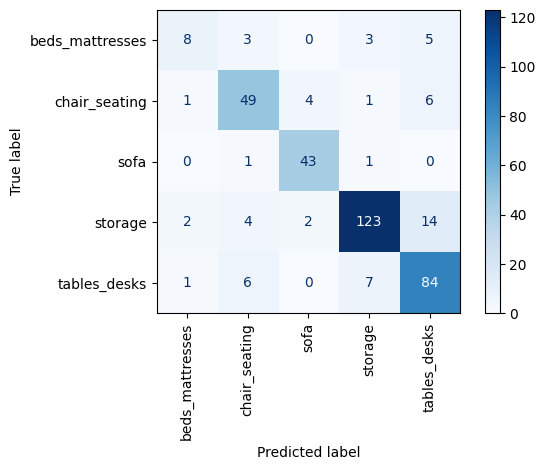

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

cm = confusion_matrix(
    all_targets,
    all_preds,
    labels=list(range(len(labels)))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(xticks_rotation=90, cmap="Blues")
plt.tight_layout()
plt.show()

## 6) Improved PyTorch model

This trains a second model from scratch using augmentation, class-balanced loss, partial MobileNetV2 fine-tuning, and best-validation checkpointing.


In [8]:
import copy
from collections import Counter

import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

improved_batch_size = 32
num_classes = len(labels)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = torch.cuda.is_available()
print(f"Training improved model on: {device}")

improved_label_to_idx = {label: idx for idx, label in enumerate(labels)}
improved_idx_to_label = {idx: label for label, idx in improved_label_to_idx.items()}

improved_weights = MobileNet_V2_Weights.DEFAULT
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

improved_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

improved_eval_transform = improved_weights.transforms()

class ImprovedItemImageDataset(Dataset):
    def __init__(self, paths, label_list, transform):
        self.paths = list(paths)
        self.labels = [improved_label_to_idx[label] for label in label_list]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

def make_improved_loader(paths, label_list, transform, shuffle=True):
    dataset = ImprovedItemImageDataset(paths, label_list, transform)
    return DataLoader(
        dataset,
        batch_size=improved_batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

improved_train_loader = make_improved_loader(train_paths, train_labels, improved_train_transform, shuffle=True)
improved_val_loader = make_improved_loader(val_paths, val_labels, improved_eval_transform, shuffle=False)
improved_test_loader = make_improved_loader(test_paths, test_labels, improved_eval_transform, shuffle=False)

improved_model = mobilenet_v2(weights=improved_weights)
for param in improved_model.features.parameters():
    param.requires_grad = False

# Fine-tune only the later feature blocks so the model adapts without overfitting too hard.
for param in improved_model.features[-4:].parameters():
    param.requires_grad = True

improved_model.classifier = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(improved_model.last_channel, num_classes),
)
improved_model = improved_model.to(device)

train_label_counts = Counter(train_labels)
class_weights = torch.tensor(
    [len(train_labels) / (num_classes * train_label_counts[label]) for label in labels],
    dtype=torch.float32,
).to(device)

improved_criterion = nn.CrossEntropyLoss(weight=class_weights)
improved_optimizer = torch.optim.AdamW(
    [
        {'params': improved_model.features[-4:].parameters(), 'lr': 1e-5},
        {'params': improved_model.classifier.parameters(), 'lr': 1e-3},
    ],
    weight_decay=1e-4,
)
improved_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer,
    mode='max',
    factor=0.5,
    patience=2,
)

def run_improved_epoch(loader, training=False):
    improved_model.train(training)
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(training):
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = improved_model(images)
            loss = improved_criterion(outputs, targets)

            if training:
                improved_optimizer.zero_grad()
                loss.backward()
                improved_optimizer.step()

            batch_size_actual = targets.size(0)
            total_loss += loss.item() * batch_size_actual
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += batch_size_actual

    return total_loss / total, correct / total

improved_epochs = 12
best_val_acc = 0.0
best_improved_state = copy.deepcopy(improved_model.state_dict())
epochs_without_improvement = 0
early_stop_patience = 4

for epoch in range(improved_epochs):
    train_loss, train_acc = run_improved_epoch(improved_train_loader, training=True)
    val_loss, val_acc = run_improved_epoch(improved_val_loader, training=False)
    improved_scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_improved_state = copy.deepcopy(improved_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1}/{improved_epochs} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} "
        f"best_val_acc={best_val_acc:.3f}"
    )

    if epochs_without_improvement >= early_stop_patience:
        print(f"Early stopping after {epoch + 1} epochs")
        break

improved_model.load_state_dict(best_improved_state)
improved_test_loss, improved_test_acc = run_improved_epoch(improved_test_loader, training=False)
print(f"Improved best val_acc={best_val_acc:.3f}")
print(f"Improved test loss={improved_test_loss:.4f} test_acc={improved_test_acc:.3f}")


Training improved model on: cuda
Epoch 1/12 train_loss=1.3214 train_acc=0.613 val_loss=1.0239 val_acc=0.772 best_val_acc=0.772
Epoch 2/12 train_loss=0.9082 train_acc=0.765 val_loss=0.8347 val_acc=0.793 best_val_acc=0.793
Epoch 3/12 train_loss=0.7701 train_acc=0.773 val_loss=0.7536 val_acc=0.826 best_val_acc=0.826
Epoch 4/12 train_loss=0.6961 train_acc=0.777 val_loss=0.7287 val_acc=0.810 best_val_acc=0.826
Epoch 5/12 train_loss=0.6125 train_acc=0.836 val_loss=0.6666 val_acc=0.826 best_val_acc=0.826
Epoch 6/12 train_loss=0.6068 train_acc=0.800 val_loss=0.6540 val_acc=0.842 best_val_acc=0.842
Epoch 7/12 train_loss=0.5678 train_acc=0.815 val_loss=0.6225 val_acc=0.853 best_val_acc=0.853
Epoch 8/12 train_loss=0.5688 train_acc=0.826 val_loss=0.6489 val_acc=0.842 best_val_acc=0.853
Epoch 9/12 train_loss=0.5361 train_acc=0.828 val_loss=0.6369 val_acc=0.826 best_val_acc=0.853
Epoch 10/12 train_loss=0.5348 train_acc=0.831 val_loss=0.6028 val_acc=0.837 best_val_acc=0.853
Epoch 11/12 train_loss=0.4

# Confusion Matrix for Improved Model

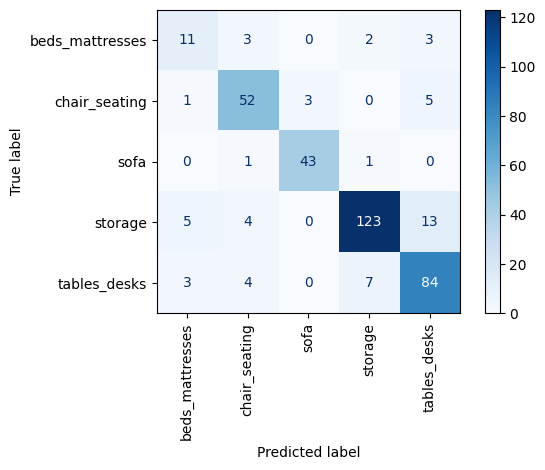

In [9]:
# Confusion Matrix for Improved Model
all_improved_preds = []
all_improved_targets = []
improved_model.eval()
with torch.no_grad():
    for images, targets in improved_test_loader:
        images = images.to(device)
        targets = targets.to(device)

        outputs = improved_model(images)
        all_improved_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_improved_targets.extend(targets.cpu().numpy())
improved_cm = confusion_matrix(
    all_improved_targets,
    all_improved_preds,
    labels=list(range(len(labels)))
)
improved_disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=labels
)
improved_disp.plot(xticks_rotation=90, cmap="Blues")
plt.tight_layout()
plt.show()

## 6) Save model artifacts

Export a model and label map to `models/` once training is in place. TODO\\


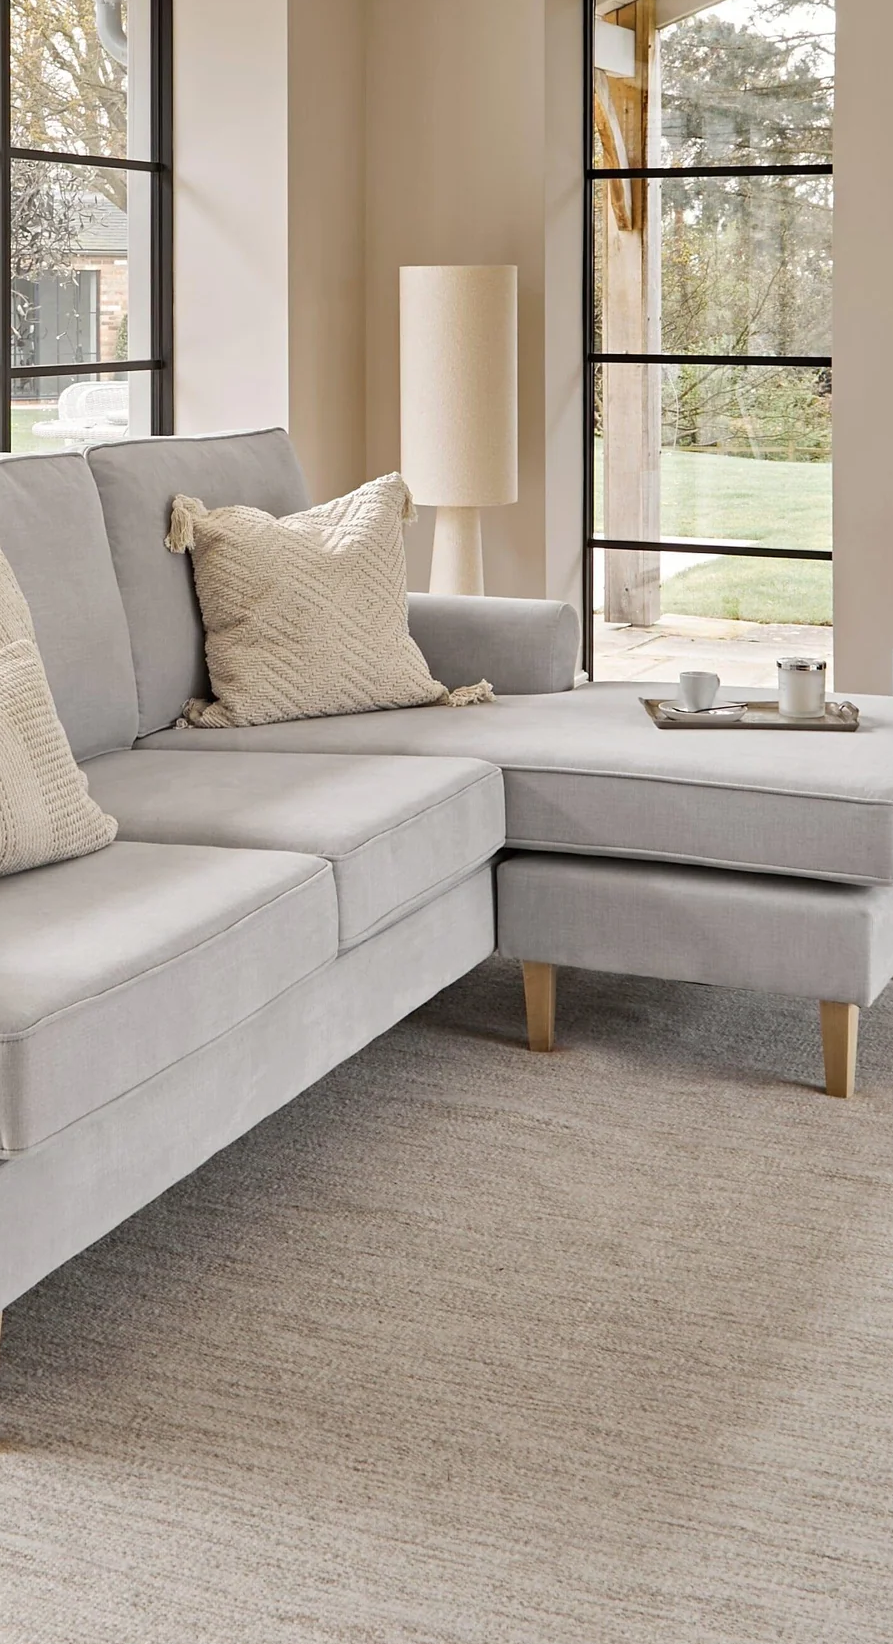

In [19]:
from pathlib import Path
from PIL import Image
import torch

# RealSense image
image_path = Path("D:\\Green Waste\\V1_GreenWaste\\data\\raw\\importedTestImages\\annabelle-corner-sofa-with-chaise-cloud-grey-with-pale-oak-legs-laura-james-2copy.webp")

image = Image.open(image_path).convert("RGB")

# Optional: crop using your manual RealSense chair annotation
label_path = Path("../labels_realsense_chair_2026-05-28-04-41-30/rgb.txt")

if label_path.exists():
    w, h = image.size
    line = label_path.read_text().strip().split()
    _, x_c, y_c, box_w, box_h = map(float, line)

    x_c *= w
    y_c *= h
    box_w *= w
    box_h *= h

    x1 = max(int(x_c - box_w / 2), 0)
    y1 = max(int(y_c - box_h / 2), 0)
    x2 = min(int(x_c + box_w / 2), w)
    y2 = min(int(y_c + box_h / 2), h)

    image = image.crop((x1, y1, x2, y2))

image

In [20]:
improved_model.eval()

input_tensor = improved_eval_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = improved_model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)[0]

top_k = min(5, len(improved_idx_to_label))
top_probs, top_idxs = torch.topk(probabilities, k=top_k)

for prob, idx in zip(top_probs, top_idxs):
    label = improved_idx_to_label[int(idx)]
    print(f"{label}: {prob.item():.3f}")

sofa: 0.399
chair_seating: 0.293
beds_mattresses: 0.149
storage: 0.132
tables_desks: 0.027
